# Proyecto INF-497 — Análisis de datos espaciales

> **Nota sobre la organización del código.** Para mantener los notebooks limpios y legibles, **la lógica de procesamiento y análisis vive en scripts `.py`** que se importan como módulos. Las celdas de este notebook se limitan a *llamar* esas funciones y a *visualizar* los resultados, evitando bloques largos de código repetido. Cada script es reproducible y reutilizable de forma independiente.

| Script | Para qué se usa |
|---|---|
| **`pipeline_sosafe.py`** (`P`) | Pipeline de procesamiento: carga los reportes SOSAFE crudos (parquet), limpia y parsea la geometría, asigna comuna, clasifica delitos, une POIs y deriva variables temporales → genera el *dataset analítico* a nivel punto. |
| **`grilla_h3.py`** (`G`) | Construye la unidad de análisis: una **grilla hexagonal H3 (Uber)** que tesela las comunas y agrega los reportes y POIs por celda (densidades, conteos). |
| **`esda_h3.py`** (`E`) | **ESDA espacial**: autocorrelación global (**I de Moran**) y local (**LISA**) sobre la grilla H3, con matriz de pesos de vecindad hexagonal. |
| **`esda_temporal.py`** (`T`) | Extensión **espacio-temporal**: cómo cambian la I de Moran y los clústeres LISA según la rebanada temporal (hora, día, estación) y en fechas especiales, sobre un soporte espacial fijo. |
| **`eda_delito.py`** (`ED`) | **EDA temporal/categórico** (no espacial) de los delitos: define subtipos de delito más finos y carga el subconjunto listo para el análisis temporal. |

Cada módulo se importa con su alias entre paréntesis y se recarga con `importlib.reload(...)` al inicio de su sección, de modo que cualquier cambio en el `.py` se refleja sin reiniciar el kernel.

# 01 - Procesamiento

In [38]:
# === Imports y configuracion global ===
import sys
import importlib

# Los modulos del proyecto viven en la carpeta scripts/ (codigo limpio y reutilizable)
if 'scripts' not in sys.path:
    sys.path.append('scripts')

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
from splot.esda import moran_scatterplot, lisa_cluster

pd.set_option('display.max_columns', None)

# Punto 1: Procesamiento de datos

**Pregunta de investigación:** ¿En qué medida la distribución espacial de puntos de interés comerciales y de transporte permite predecir los focos de mayor exposición al delito en cinco comunas de la Región Metropolitana mediante reportes ciudadanos?
**Fuentes**
- `reports/*.parquet`: reportes ciudadanos de **SOSAFE** (nov-2023 a mar-2025), con geometría WKB (EPSG:4326), `type`, `created_at`, `hour`, `dow`, `h3_cell_id`, `direct_migrant_mention`.
- `dataset_pois.csv`: puntos de interés de **Google Places** (botillerías, discotecas, estaciones de metro, comisarías) en las 5 comunas.
- `comunas.geojson`: límites comunales (OpenStreetMap / Nominatim, cacheados).

In [39]:
import pipeline_sosafe as P
importlib.reload(P)
import grilla_h3 as G
importlib.reload(G)

<module 'grilla_h3' from 'c:\\Users\\flavi\\Desktop\\Analisis de datos espaciales\\Proyecto\\scripts\\grilla_h3.py'>

## 1. Carga de los reportes SOSAFE
Se concatenan los 484 parquet diarios en un único DataFrame maestro (~2,0 M de reportes).

In [40]:
df = P.cargar_reportes()

[1] Carga: 484 archivos -> 2,007,713 reportes crudos


## 2. Geometría y limpieza
- WKB → puntos en un `GeoDataFrame` (EPSG:4326).
- Se descartan geometrías nulas y coordenadas fuera del *bounding box* de la Región Metropolitana (GPS erróneos).
- **Deduplicación**: mismo texto + mismo instante + mismo tipo + misma coordenada = reporte repetido.
- El texto ya viene en **UTF-8 correcto** (tildes y emojis íntegros); no requiere reparación de encoding.

In [41]:
gdf = P.limpiar(df)
print(gdf.crs)
gdf[['type', 'created_at', 'hour', 'dow', 'geometry']].head(3)

[2] Limpieza: 2,007,713 -> sin geom nula/bbox 2,007,713 -> sin duplicados 2,007,629
EPSG:4326


,type,created_at,hour,dow,geometry
0,6,2023-11-28 21:12:11-03:00,21,1,POINT (-70.6313 -33.46381)
1,32,2023-11-28 21:13:11-03:00,21,1,POINT (-70.54154 -33.57743)
2,1,2023-11-28 21:28:11-03:00,21,1,POINT (-70.57496 -33.40328)


## 3. Límites comunales (unidad de recorte)
Los polígonos de las 5 comunas se obtienen de Nominatim (OSM) y se **cachean** en `comunas.geojson` para reproducibilidad (no depende de la red en corridas posteriores).

[3] Comunas: shapefile INE Censo 2017 (5 comunas) -> cache comunas.geojson


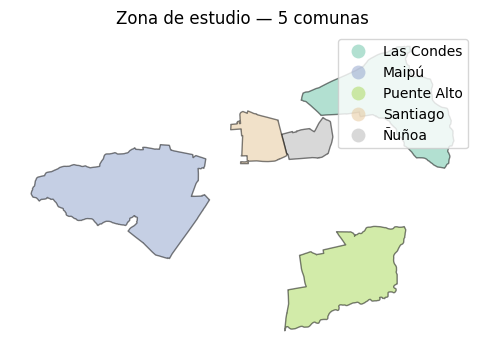

In [42]:
comunas = P.obtener_comunas()
ax = comunas.to_crs(32719).plot(column='comuna', figsize=(6, 6), edgecolor='black',
                                legend=True, alpha=0.5, cmap='Set2')
ax.set_title('Zona de estudio — 5 comunas'); ax.set_axis_off()
plt.show()

## 4. Asignación de comuna y recorte
*Spatial join* punto-en-polígono (`within`): cada reporte recibe su comuna y se conserva solo lo que cae dentro de la zona de estudio.

In [43]:
gdf = P.asignar_comuna(gdf, comunas)

[4] Recorte a las 5 comunas: 2,007,629 -> 876,449 dentro de la zona de estudio
    comuna
    Santiago       250785
    Maipú          221024
    Ñuñoa          145188
    Las Condes     132004
    Puente Alto    127448


## 5. Clasificación — variable objetivo `es_delito`
El código `type` de SOSAFE es **ruidoso** (los vecinos miscategorizan; existen cajones de sastre como 17/31/33). Por eso `es_delito` combina dos señales:

$$\text{es\_delito} = (\text{type} \in \{0,1,2,6\}) \;\lor\; (\text{descripción contiene keyword de delito})$$

con keywords como *robo, asalto, portonazo, encerrona, lanza, balacera, ...* (sobre texto normalizado sin tildes).

In [44]:
gdf = P.clasificar(gdf)
gdf['categoria_inferida'].value_counts().head(10)

[5] Clasificacion: es_delito = 117,383 (13.4%)  | por type=74,749 | por keyword=72,098


categoria_inferida
otro                 332308
mascotas             180330
ruidos_molestos       88977
marketplace           61851
disturbios            59183
sospechoso            49305
mal_estacionado       15851
electricidad          14991
asalto                13860
bomberos_incendio     10058
Name: count, dtype: int64

## 6. Manejo de CRS y unión con los POIs
Para medir distancias en **metros** se reproyecta a UTM 19S (**EPSG:32719**). Por cada reporte y cada categoría de POI se calcula (vía `cKDTree`):
- `dist_<cat>_m`: distancia al POI más cercano.
- `n_<cat>_200m`, `n_<cat>_500m`: conteo de POIs dentro del radio (densidad local).

In [45]:
gdf = P.unir_pois(gdf)
[c for c in gdf.columns if c.startswith(('dist_', 'n_'))]

[6] Union POIs: distancia + conteos (radios (200, 500) m) por categoria ['botilleria', 'comisaria', 'discoteca', 'estacion de metro']


['dist_botilleria_m',
 'n_botilleria_200m',
 'n_botilleria_500m',
 'dist_comisaria_m',
 'n_comisaria_200m',
 'n_comisaria_500m',
 'dist_discoteca_m',
 'n_discoteca_200m',
 'n_discoteca_500m',
 'dist_estacion_de_metro_m',
 'n_estacion_de_metro_200m',
 'n_estacion_de_metro_500m']

## 7. Variables derivadas temporales
`fecha`, `anio`, `mes`, `fin_de_semana` (dow 5–6), `periodo` (madrugada/mañana/tarde/noche) y `nocturno` (20–05 h, ventana asociada a alcohol/ocio).

In [46]:
gdf = P.derivar_temporales(gdf)

[7] Variables derivadas: fecha, anio, mes, fin_de_semana, periodo, nocturno


## 8. Guardado del dataset analítico
Resultado: `dataset_analitico.parquet` a nivel de punto, base para la agregación a **grilla** (Punto 2) y el análisis espacial (Punto 3).

In [47]:
out = P.guardar(gdf)

[8] Guardado: dataset_analitico.parquet  (876,449 filas, 34 columnas)


## 9. Mini análisis exploratorio

In [48]:
print('Tasa de delito por comuna (%):')
print((gdf.groupby('comuna')['es_delito'].mean() * 100).round(1))
print('\nTasa de delito nocturno vs diurno (%):')
print((gdf.groupby('nocturno')['es_delito'].mean() * 100).round(1))
print('\nDistancia a botillería (m), mediana, delito vs no-delito:')
print(gdf.groupby('es_delito')['dist_botilleria_m'].median().round(1))

Tasa de delito por comuna (%):
comuna
Las Condes      9.0
Maipú          10.7
Puente Alto    11.0
Santiago       19.2
Ñuñoa          13.6
Name: es_delito, dtype: float64

Tasa de delito nocturno vs diurno (%):
nocturno
False    11.3
True     16.2
Name: es_delito, dtype: float64

Distancia a botillería (m), mediana, delito vs no-delito:
es_delito
False    337.4
True     317.5
Name: dist_botilleria_m, dtype: float64


# Punto 2: Unidad de análisis (grilla H3) y agregación espacial

Pasamos del dataset a **nivel de punto** (`dataset_analitico.parquet`, 876k reportes) a un dataset **agregado por unidad espacial**, requisito para responder *"¿qué **zonas** tienen mayor exposición al delito?"*.

## Justificación de la unidad: hexágonos H3 (Uber) resolución 8


 **Comuna**  Solo 5 unidades → imposible medir autocorrelación espacial; oculta la heterogeneidad **intra**-comunal que es justo el foco. 
 **Manzana  zona censal** Polígonos de área **desigual** y fronteras irregulares → sesga densidades y la matriz de vecindad; además no alinea con la grilla de los POIs. 
 **Grilla cuadrada**  Vecindad ambigua (4 vs 8 vecinos), efecto de esquinas. 
 **H3 res 8 (≈0,74 km²)**  **Área uniforme** (densidades comparables) y **vecindad regular de 6** (mejor para Moran/LISA). 488 celdas con reportes, conteos estables (mediana ~807 reportes/celda) → tasas robustas. Los reportes ya traían `h3_cell_id`, y H3 es jerárquico (permite análisis de sensibilidad de escala / MAUP en res 9). 

In [49]:
import grilla_h3 as G
importlib.reload(G)

<module 'grilla_h3' from 'c:\\Users\\flavi\\Desktop\\Analisis de datos espaciales\\Proyecto\\scripts\\grilla_h3.py'>

## 1. Construcción de la grilla y agregación
`construir_grilla()` (1) tesela las 5 comunas con `h3.polygon_to_cells` (cobertura completa, incluye celdas con 0 reportes), (2) agrega los reportes por celda (`n_reportes`, `n_delito`, nocturnos…), (3) agrega los POIs por categoría, y (4) arma el `GeoDataFrame` con los polígonos hexagonales y variables derivadas (`tasa_delito`, `dens_delito_km2`, `dens_botilleria_km2`).


In [50]:
grid = G.construir_grilla(filtro_fecha=('2024-01-01', '2024-01-31'))  # enero 2024 (rango de color legible)

[1] Teselado: 563 celdas H3 res8 cubren las 5 comunas
    filtro de fechas 2024-01-01 a 2024-01-31: 46,412 reportes
[2] Reportes agregados: 416 celdas con al menos 1 reporte
[3] POIs agregados: 301 celdas con al menos 1 POI  (['n_botilleria', 'n_comisaria', 'n_discoteca', 'n_estacion_de_metro', 'n_pois_total'])
[4] Grilla: 696 celdas | con reportes=416 | con POIs=301


## 2. Estadísticas descriptivas (global y por comuna)

In [51]:
print('Celdas:', len(grid), '| con reportes:', int((grid.n_reportes > 0).sum()),
      '| con POIs:', int((grid.n_pois_total > 0).sum()))
display(grid[['n_reportes', 'n_delito', 'tasa_delito', 'dens_delito_km2',
              'n_botilleria']].describe().round(3))
grid.groupby('comuna').agg(celdas=('h3', 'size'), reportes=('n_reportes', 'sum'),
                           delitos=('n_delito', 'sum'),
                           tasa_delito_med=('tasa_delito', 'median'),
                           botillerias=('n_botilleria', 'sum')).round(3)

Celdas: 696 | con reportes: 416 | con POIs: 301


,n_reportes,n_delito,tasa_delito,dens_delito_km2,n_botilleria
count,696.000,696.000,416.000,696.000,696.000
mean,66.684,10.178,0.151,15.969,0.598
std,137.749,24.562,0.144,38.516,1.122
min,0.000,0.000,0.000,0.000,0.000
25%,0.000,0.000,0.081,0.000,0.000
50%,6.000,1.000,0.133,1.568,0.000
75%,82.250,11.000,0.184,17.256,1.000
max,1640.000,281.000,1.000,440.639,7.000


,celdas,reportes,delitos,tasa_delito_med,botillerias
comuna,,,,,
Las Condes,168,7018,701,0.095,26
Maipú,224,10512,1442,0.142,109
Puente Alto,150,5475,791,0.122,67
Santiago,49,14855,2860,0.183,96
Ñuñoa,38,8552,1290,0.141,40


## 3. Mapas temáticos
Esquemas de clasificación justificados: **cuantiles** para variables muy sesgadas (densidad de delito) y **Fisher–Jenks** (cortes naturales) para conteos de POIs.

**Estabilidad de tasas:** las tasas en celdas con muy pocos reportes son ruidosas (una celda de borde con 1 reporte puede dar 0 % o 100 %). Por eso el mapa de `tasa_delito` se restringe a celdas con **≥ 30 reportes**; la **densidad** (delitos/km²) no sufre este problema y se mapea completa.

c:\Users\flavi\miniconda3\envs\HealthPytorch\Lib\site-packages\mapclassify\classifiers.py:1767: UserWarning: Not enough unique values in array to form 5 classes. Setting k to 4.
  self.bins = quantile(y, k=k)


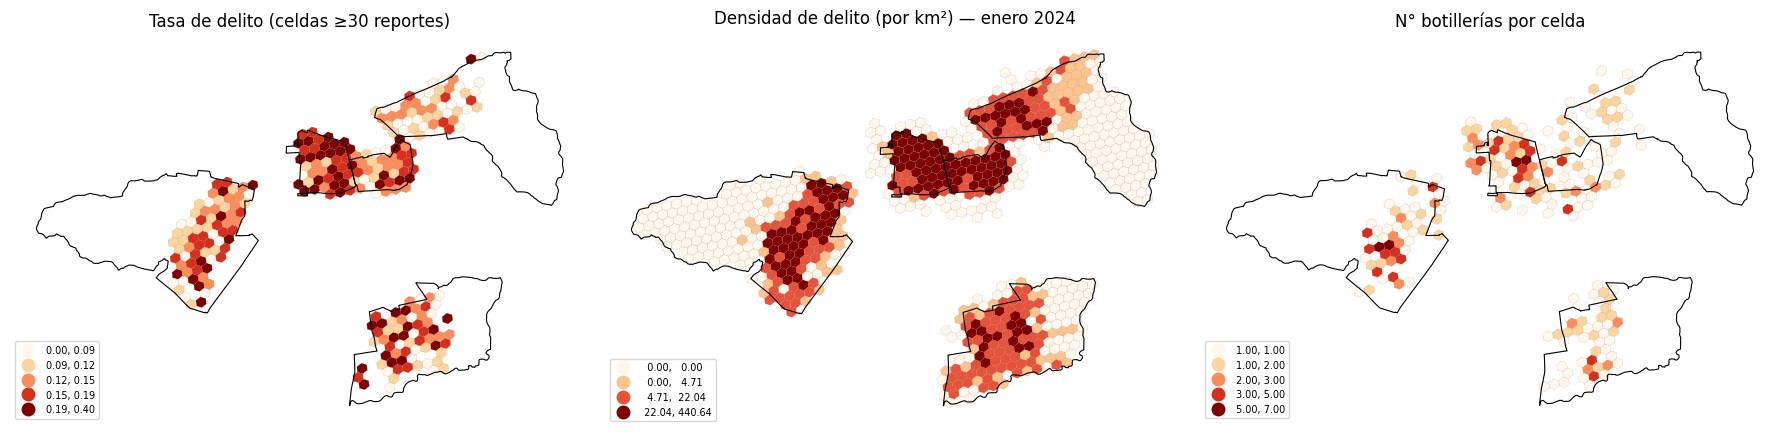

In [52]:
com = gpd.read_file('comunas.geojson').to_crs(grid.crs)
fig, axes = plt.subplots(1, 3, figsize=(18, 7))

capas = [
    (grid[grid.n_reportes >= 30], 'tasa_delito', 'quantiles',
     'Tasa de delito (celdas ≥30 reportes)'),
    (grid, 'dens_delito_km2', 'quantiles', 'Densidad de delito (por km²) — enero 2024'),
    (grid[grid.n_botilleria > 0], 'n_botilleria', 'fisherjenks', 'N° botillerías por celda'),
]
for ax, (capa, col, scheme, titulo) in zip(axes, capas):
    capa.plot(column=col, scheme=scheme, k=5, cmap='OrRd', legend=True,
              legend_kwds={'fmt': '{:.2f}', 'loc': 'lower left', 'fontsize': 7},
              edgecolor='grey', linewidth=0.1, ax=ax)
    com.boundary.plot(ax=ax, color='black', linewidth=0.8)
    ax.set_title(titulo); ax.set_axis_off()
plt.tight_layout(); plt.show()


- La **densidad de delito** se concentra de forma marcada en **Santiago centro** y en los núcleos de Maipú/Puente Alto, no de manera homogénea → hay **estructura espacial** evidente.
- Las **botillerías** se concentran en los mismos núcleos, lo que motiva medir su asociación espacial con el delito.

La grilla queda guardada en `grilla_h3_res8.gpkg` (ejecutar `python grilla_h3.py` o `G.main()`).

## 4. Grilla más fina (res 9 ≈ 0,10 km²) y POIs

La **misma** construcción a **resolución 9** (~0,10 km², ≈ tamaño de barrio): ~4.360 celdas, 
más **específica** que la res 8 — revela la estructura *dentro* del centro que la res 8 promedia 
(a costa de tasas algo más ruidosas). El segundo mapa superpone los **POIs** sobre la grilla fina 
para ver su coincidencia con las zonas de alta densidad de delito.

[1] Teselado: 4,020 celdas H3 res9 cubren las 5 comunas
    filtro de fechas 2024-01-01 a 2024-01-31: 46,412 reportes
[2] Reportes agregados: 2,148 celdas con al menos 1 reporte
[3] POIs agregados: 600 celdas con al menos 1 POI  (['n_botilleria', 'n_comisaria', 'n_discoteca', 'n_estacion_de_metro', 'n_pois_total'])
[4] Grilla: 4,300 celdas | con reportes=2,148 | con POIs=600
res9: 4300 celdas | 2148 con reportes


c:\Users\flavi\miniconda3\envs\HealthPytorch\Lib\site-packages\mapclassify\classifiers.py:1767: UserWarning: Not enough unique values in array to form 6 classes. Setting k to 4.
  self.bins = quantile(y, k=k)


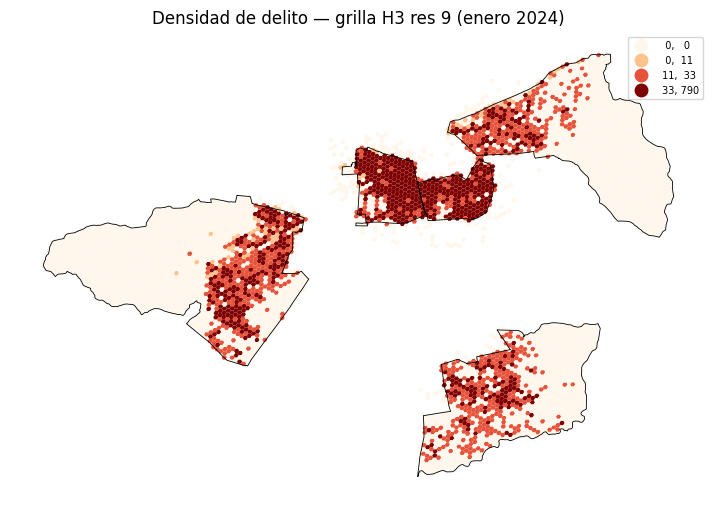

In [53]:
# Grilla H3 más fina (res 9) — más específica (enero 2024)
grid9 = G.construir_grilla(res=9, filtro_fecha=('2024-01-01', '2024-01-31'))
print('res9:', len(grid9), 'celdas |', int((grid9.n_reportes > 0).sum()), 'con reportes')

com = gpd.read_file('comunas.geojson').to_crs(grid9.crs)
fig, ax = plt.subplots(figsize=(9, 9))
grid9.plot(column='dens_delito_km2', scheme='quantiles', k=6, cmap='OrRd', legend=True,
           legend_kwds={'fmt': '{:.0f}', 'fontsize': 7}, edgecolor='none', ax=ax)
com.boundary.plot(ax=ax, color='black', linewidth=0.6)
ax.set_title('Densidad de delito — grilla H3 res 9 (enero 2024)'); ax.set_axis_off()
plt.show()

# 03 - ESDA: Moran y LISA

Sobre la grilla H3 res 8 (`grilla_h3_res8.gpkg`) medimos la **estructura espacial** de la exposición al delito.


In [54]:
import esda_h3 as E
importlib.reload(E)

g, w, mi, lisa = E.analizar()   # construye W (H3 k=1), Moran global y LISA

[Moran global] variable='dens_delito_km2'  n=396 celdas  islas removidas=1
   I = 0.683   E[I] = -0.003   z = 23.89   p(perm) = 0.0010

[LISA] clusters significativos (p<0.05): 104 de 396 celdas
lisa_cluster
No significativo        292
Bajo-Bajo (coldspot)     67
Alto-Alto (hotspot)      36
Bajo-Alto                 1


## 1. Autocorrelación global — I de Moran

I de Moran = 0.683
E[I] bajo aleatoriedad = -0.003
z = 23.89   pseudo p-valor (999 permutaciones) = 0.0010


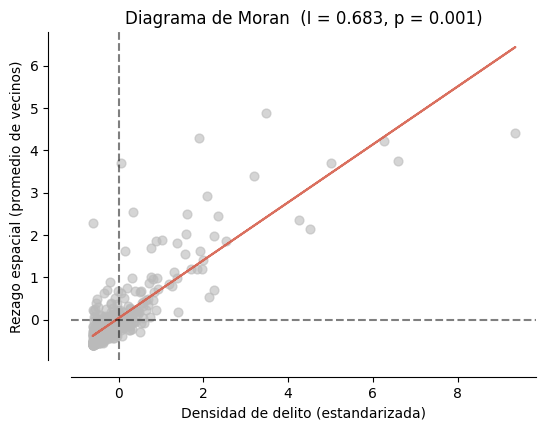

In [55]:
print(f'I de Moran = {mi.I:.3f}')
print(f'E[I] bajo aleatoriedad = {mi.EI:.3f}')
print(f'z = {mi.z_sim:.2f}   pseudo p-valor (999 permutaciones) = {mi.p_sim:.4f}')

fig, ax = plt.subplots(figsize=(6, 6))
moran_scatterplot(mi, ax=ax, aspect_equal=True)
ax.set_xlabel('Densidad de delito (estandarizada)')
ax.set_ylabel('Rezago espacial (promedio de vecinos)')
ax.set_title(f'Diagrama de Moran  (I = {mi.I:.3f}, p = {mi.p_sim:.3f})')
plt.show()

 **Resultado:** I ≈ **0,68** (p = 0,001) → autocorrelación espacial **positiva, fuerte y significativa**. La exposición al delito se concentra en clusters; la pendiente del diagrama de Moran es justamente el valor de I.

## 2. Autocorrelación local — clusters LISA
Mapa de los clusters significativos (p < 0,05): dónde están los *hotspots* y *coldspots*.

lisa_cluster
No significativo        292
Bajo-Bajo (coldspot)     67
Alto-Alto (hotspot)      36
Bajo-Alto                 1


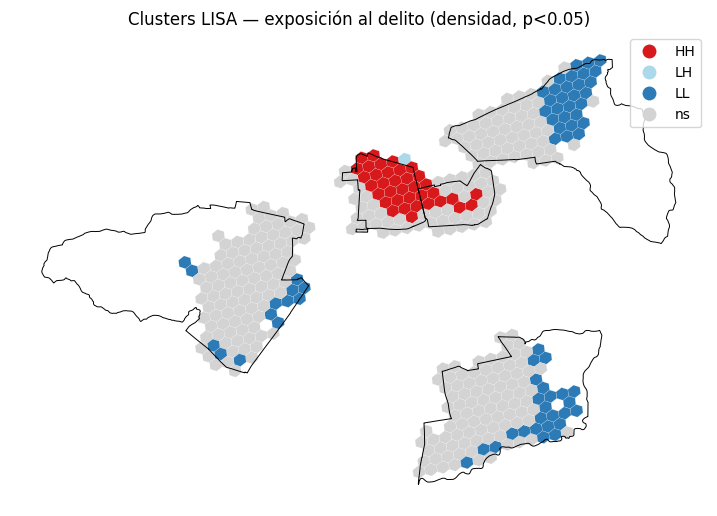

In [56]:
print(g['lisa_cluster'].value_counts().to_string())

com = gpd.read_file('comunas.geojson').to_crs(g.crs)
fig, ax = plt.subplots(figsize=(9, 9))
lisa_cluster(lisa, g, p=0.05, ax=ax, legend=True)
com.boundary.plot(ax=ax, color='black', linewidth=0.7)
ax.set_title('Clusters LISA — exposición al delito (densidad, p<0.05)')
ax.set_axis_off()
plt.show()

 El **hotspot Alto-Alto** se ubica en **Santiago centro** y su borde con Ñuñoa; los **coldspots Bajo-Bajo** en el oriente de Las Condes y en bordes de Maipú/Puente Alto. Esto responde directamente la pregunta: las zonas de mayor exposición están espacialmente delimitadas y son identificables.

## 3. Caracterización de los hotspots
¿Qué distingue a las celdas hotspot? Comparamos las medias de los *hotspots* (Alto-Alto) contra el resto.

In [57]:
g['es_hotspot'] = g['lisa_cluster'].str.startswith('Alto-Alto')
cols = ['dens_delito_km2', 'tasa_delito', 'dens_botilleria_km2', 'n_botilleria',
        'n_discoteca', 'n_estacion_de_metro', 'prop_nocturno']
tabla = g.groupby('es_hotspot')[cols].mean().round(3).T
tabla.columns = ['Resto', 'Hotspot (HH)']
tabla['ratio'] = (tabla['Hotspot (HH)'] / tabla['Resto']).round(1)
tabla

,Resto,Hotspot (HH),ratio
dens_delito_km2,296.424,2147.636,7.2
tasa_delito,0.114,0.184,1.6
dens_botilleria_km2,1.125,3.397,3.0
n_botilleria,0.717,2.167,3.0
n_discoteca,0.069,0.694,10.1
n_estacion_de_metro,0.847,1.722,2.0
prop_nocturno,0.399,0.477,1.2


Los *hotspots* de delito concentran **3× más densidad de botillerías, ~10× más discotecas, 2× más estaciones de metro y mayor actividad nocturna** que el resto. Esto sugiere una **asociación espacial entre la oferta de alcohol/ocio nocturno y la exposición al delito**.

# 4) Análisis espacio-temporal


In [58]:
import esda_temporal as T
importlib.reload(T)

pts, w, area, geom = T.preparar()
com = gpd.read_file('comunas.geojson').to_crs(geom.crs)
print(f'{len(pts):,} reportes en el soporte fijo de {w.n} celdas')

875,663 reportes en el soporte fijo de 396 celdas


## 1. Tabla comparativa — I de Moran global por rebanada
Para días/horas/estaciones se reporta también el n° de *hotspots* (HH) y *coldspots* (LL) LISA; para las fechas especiales solo el Moran global (los conteos diarios son muy escasos para una significancia LISA fiable).

In [59]:
filas = []
for label, mask in T.definir_slices(pts).items():
    res, _ = T.morlisa(pts, mask, w, area, label)
    filas.append(res)
for label, mask in T.slices_especiales(pts).items():
    res, _ = T.morlisa(pts, mask, w, area, label, lisa=False)
    filas.append(res)
pd.DataFrame(filas)

,slice,n_delito,I,p,z,n_hotspot,n_coldspot
0,Nocturno (20-05h),60552,0.656,0.001,22.71,36.0,61.0
1,Diurno (06-19h),56741,0.693,0.001,24.24,34.0,79.0
2,Fin de semana,35100,0.680,0.001,23.59,36.0,63.0
3,Dia de semana,82193,0.679,0.001,23.76,35.0,69.0
4,Verano 2024 (D-E-F),22145,0.669,0.001,23.39,35.0,81.0
5,Invierno 2024 (J-J-A),20318,0.636,0.001,22.14,34.0,63.0
6,Madrugada (0-5h),24677,0.651,0.001,22.11,35.0,58.0
7,Manana (6-11h),15552,0.689,0.001,24.28,32.0,73.0
8,Tarde (12-18h),33760,0.698,0.001,24.09,35.0,78.0
9,Noche (19-23h),43304,0.638,0.001,22.45,36.0,67.0


La I de Moran es **muy estable (~0,64–0,70)** y siempre significativa, con ~35 hotspots en todas las rebanadas → la estructura espacial del delito es **persistente** (el hotspot de Santiago centro domina a toda hora/día/estación). **Excepciones:** **18-Sep (I=0,49)** y **Año Nuevo (I=0,61)** muestran un patrón **más disperso** que un día normal (I≈0,67): durante las festividades el delito se reparte hacia la periferia.

## 2. LISA por hora y por día

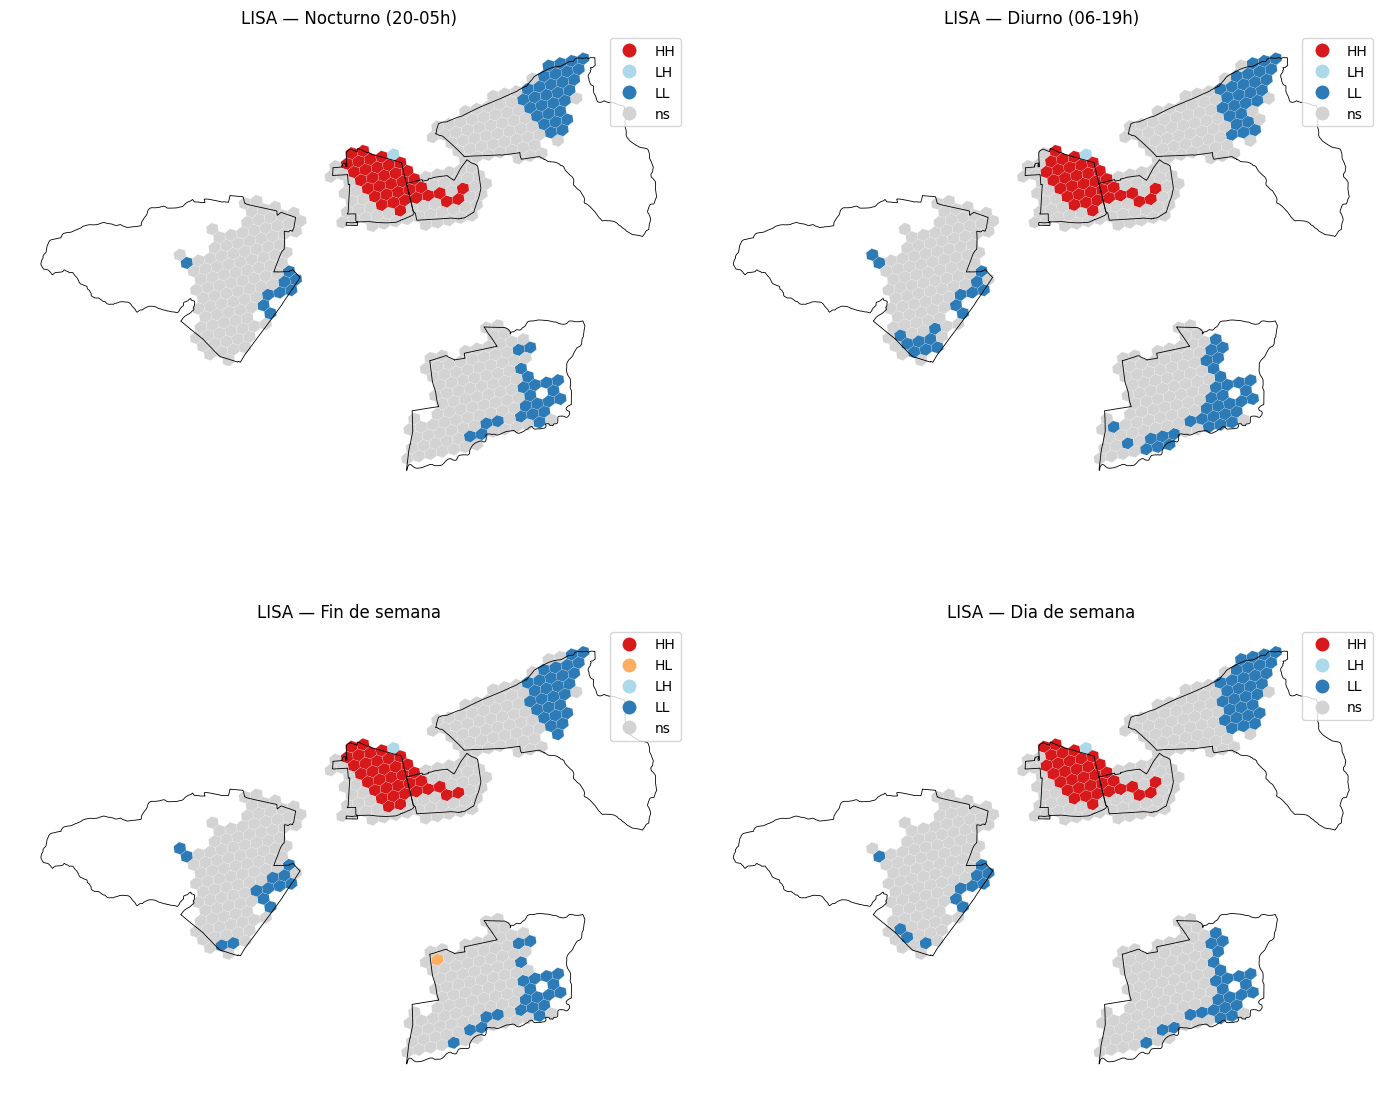

In [60]:
fig, ax = plt.subplots(2, 2, figsize=(14, 13))
for a, lab in zip(ax.ravel(), ['Nocturno (20-05h)', 'Diurno (06-19h)',
                               'Fin de semana', 'Dia de semana']):
    _, out = T.morlisa(pts, T.definir_slices(pts)[lab], w, area, lab)
    T.mapa_lisa(out, geom, com, a, f'LISA — {lab}')
plt.tight_layout(); plt.show()

## 3. LISA por periodo del día

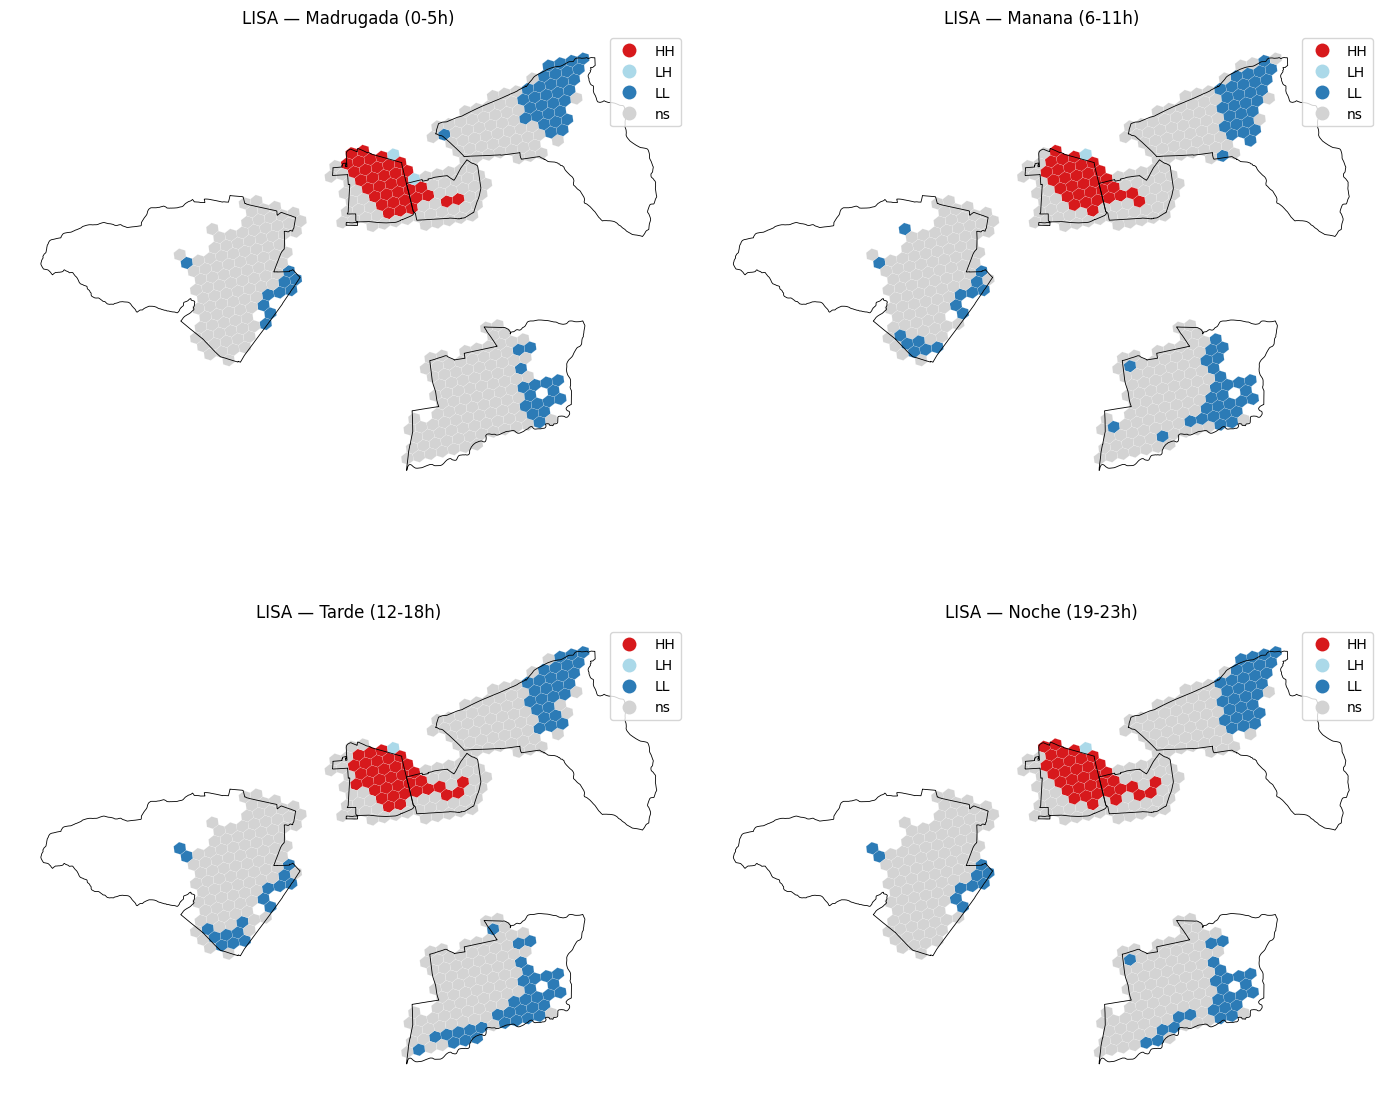

In [61]:
fig, ax = plt.subplots(2, 2, figsize=(14, 13))
for a, lab in zip(ax.ravel(), ['Madrugada (0-5h)', 'Manana (6-11h)',
                               'Tarde (12-18h)', 'Noche (19-23h)']):
    _, out = T.morlisa(pts, T.definir_slices(pts)[lab], w, area, lab)
    T.mapa_lisa(out, geom, com, a, f'LISA — {lab}')
plt.tight_layout(); plt.show()

## 4. Verano vs Invierno 2024 LISA

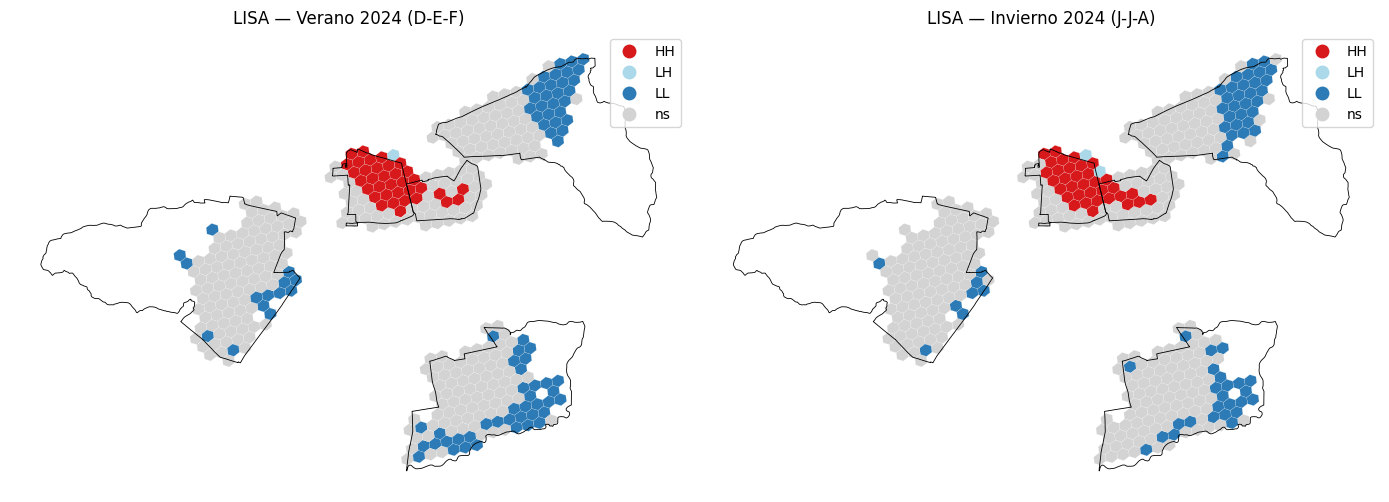

In [62]:
fig, ax = plt.subplots(1, 2, figsize=(14, 7))
for a, lab in zip(ax, ['Verano 2024 (D-E-F)', 'Invierno 2024 (J-J-A)']):
    _, out = T.morlisa(pts, T.definir_slices(pts)[lab], w, area, lab)
    T.mapa_lisa(out, geom, com, a, f'LISA — {lab}')
plt.tight_layout(); plt.show()

## Conclusiones espacio-temporales
- **Persistencia:** el hotspot de exposición al delito (Santiago centro) es **estructural** — está presente a toda hora, día y estación (I de Moran ~0,67 estable). Esto es una buena noticia para un modelo **predictivo**: la geografía del riesgo es estable en el tiempo.
- **Matices** menores: el patrón diurno/tarde está algo más concentrado que el nocturno/madrugada; el verano algo más que el invierno.


# 05 - EDA Temporal

Análisis **no espacial** 

Se define un **subtipo de delito** más fino que `categoria_inferida`, combinando el código `type` (más confiable) con grupos de keywords (`eda_delito.clasificar_subtipo`): *robo_hurto, asalto_violento, armas_disparos, drogas, sospechoso, vandalismo, otro_delito*.

In [63]:
import eda_delito as ED
importlib.reload(ED)

d = ED.cargar_delitos()
# orden de subtipos para los graficos, excluyendo VIF (subdetectado)
orden = [t for t in ED.ORDEN_SUBTIPOS
         if t in d['tipo_delito'].unique() and t != 'violencia_intrafamiliar']
print(f'Delitos: {len(d):,}')
d['tipo_delito'].value_counts()

Delitos: 117,383


tipo_delito
sospechoso                 39118
robo_hurto                 26321
asalto_violento            23273
drogas                     13678
armas_disparos              9813
otro_delito                 4875
vandalismo                   301
violencia_intrafamiliar        4
Name: count, dtype: int64

## 1. ¿A qué hora ocurre cada tipo de delito?

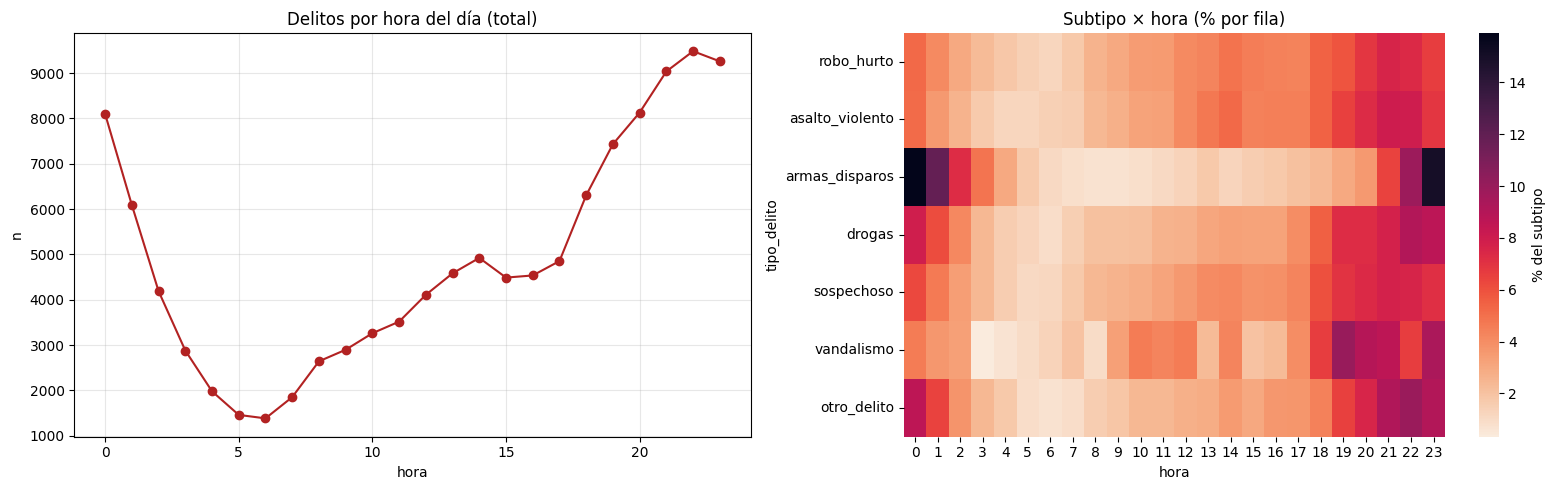

In [64]:
fig, ax = plt.subplots(1, 2, figsize=(16, 5))
# curva total por hora
d['hour'].value_counts().sort_index().plot(ax=ax[0], marker='o', color='firebrick')
ax[0].set_title('Delitos por hora del día (total)'); ax[0].set_xlabel('hora'); ax[0].set_ylabel('n')
ax[0].grid(alpha=0.3)
# heatmap subtipo x hora (% por fila -> perfil horario de cada subtipo)
piv = pd.crosstab(d['tipo_delito'], d['hour']).loc[orden]
pivn = piv.div(piv.sum(axis=1), axis=0) * 100
sns.heatmap(pivn, cmap='rocket_r', ax=ax[1], cbar_kws={'label': '% del subtipo'})
ax[1].set_title('Subtipo × hora (% por fila)'); ax[1].set_xlabel('hora')
plt.tight_layout(); plt.show()

El delito en general **sube en la tarde-noche y peaks ~21–23 h**. Pero el perfil difiere por tipo: **armas/disparos se concentra a medianoche (0–2 h)** y es el más nocturno, mientras robo y asalto peakean antes (20–22 h).

## 2. Histograma de los dias de la semana — y el heatmap hora × día

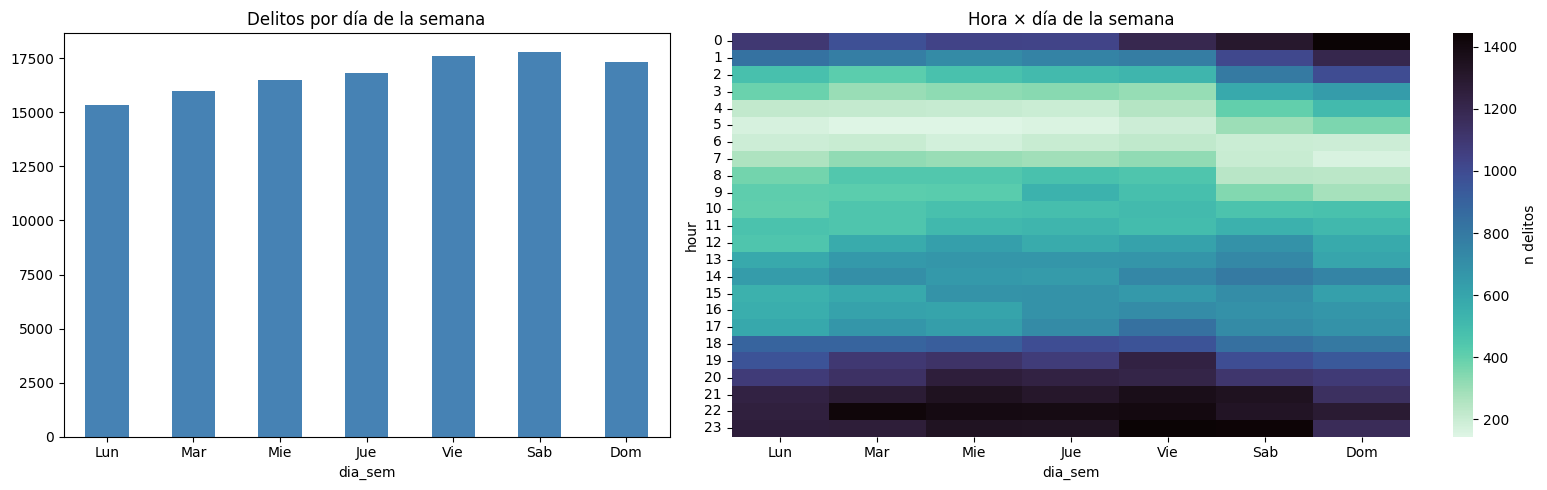

In [65]:
dias = ['Lun', 'Mar', 'Mie', 'Jue', 'Vie', 'Sab', 'Dom']
fig, ax = plt.subplots(1, 2, figsize=(16, 5), gridspec_kw={'width_ratios': [1, 1.4]})
d['dia_sem'].value_counts().loc[dias].plot.bar(ax=ax[0], color='steelblue')
ax[0].set_title('Delitos por día de la semana'); ax[0].tick_params(axis='x', rotation=0)
piv2 = pd.crosstab(d['hour'], d['dia_sem'])[dias]
sns.heatmap(piv2, cmap='mako_r', ax=ax[1], cbar_kws={'label': 'n delitos'})
ax[1].set_title('Hora × día de la semana')
plt.tight_layout(); plt.show()

El delito se concentra en las **noches de viernes, sábado y domingo** (esquina inferior-derecha del heatmap), coherente con el patrón de ocio nocturno asociado a botillerías/discotecas del análisis espacial.

## 3. Evolución en el tiempo y fechas especiales (2024)

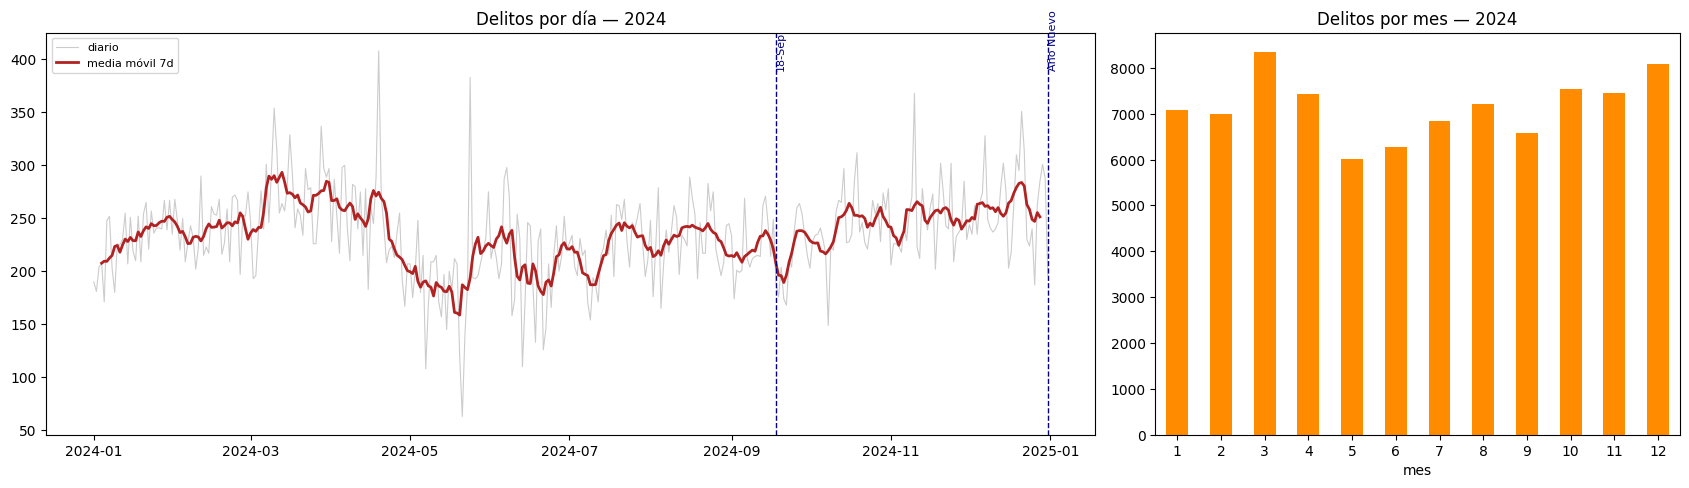

In [66]:
d24 = d[d['anio'] == 2024]
fig, ax = plt.subplots(1, 2, figsize=(17, 5), gridspec_kw={'width_ratios': [2, 1]})
s = d24.groupby('fecha').size()
ax[0].plot(s.index, s.values, color='grey', alpha=0.4, lw=0.8, label='diario')
ax[0].plot(s.index, s.rolling(7, center=True).mean(), color='firebrick', lw=2, label='media móvil 7d')
for f, txt in [('2024-09-18', '18-Sep'), ('2024-12-31', 'Año Nuevo')]:
    ax[0].axvline(pd.Timestamp(f), color='navy', ls='--', lw=1)
    ax[0].text(pd.Timestamp(f), s.max() * 0.96, txt, rotation=90, fontsize=8, color='navy')
ax[0].set_title('Delitos por día — 2024'); ax[0].legend(fontsize=8)
d24.groupby('mes').size().plot.bar(ax=ax[1], color='darkorange')
ax[1].set_title('Delitos por mes — 2024'); ax[1].tick_params(axis='x', rotation=0)
plt.tight_layout(); plt.show()

## 4. Composición del delito por comuna

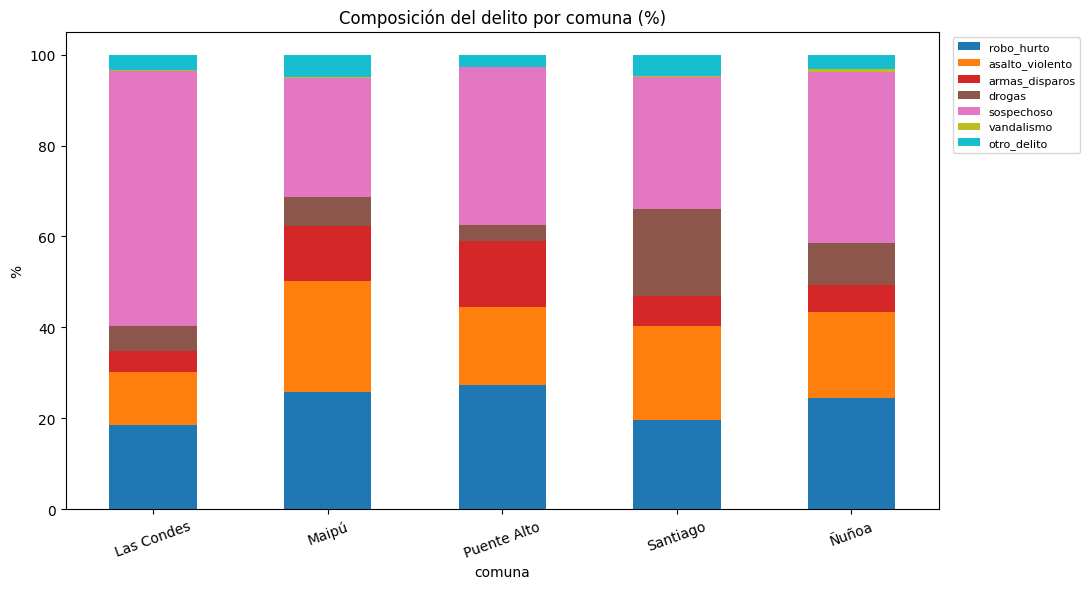

tipo_delito,robo_hurto,asalto_violento,armas_disparos,drogas,sospechoso,vandalismo,otro_delito
comuna,,,,,,,
Las Condes,18.5,11.7,4.6,5.6,56.1,0.1,3.4
Maipú,25.7,24.5,12.1,6.4,26.2,0.3,4.9
Puente Alto,27.3,17.1,14.5,3.7,34.6,0.0,2.8
Santiago,19.5,20.7,6.6,19.2,29.0,0.2,4.8
Ñuñoa,24.4,18.9,6.1,9.1,37.7,0.7,3.1


In [67]:
comp = pd.crosstab(d['comuna'], d['tipo_delito'], normalize='index')[orden] * 100
ax = comp.plot.bar(stacked=True, figsize=(11, 6), colormap='tab10')
ax.set_title('Composición del delito por comuna (%)'); ax.set_ylabel('%')
ax.tick_params(axis='x', rotation=20)
ax.legend(bbox_to_anchor=(1.01, 1), fontsize=8)
plt.tight_layout(); plt.show()
comp.round(1)

El **mix** de delito cambia por comuna: en **Las Condes** domina lo *sospechoso* (percepción), mientras **Maipú y Puente Alto** tienen mayor proporción de *robo* y *armas/disparos*, y **Santiago/Ñuñoa** más *drogas*. La exposición no solo difiere en intensidad sino en **naturaleza**.

## 5. Decaimiento de la distancia al POI (criminología ambiental)

¿La probabilidad de delito cae al alejarse de la oferta de alcohol/ocio/transporte?

- **Izquierda:** la **tasa de delito** por banda de distancia al POI más cercano.
- **Derecha:** la **distribución** de distancias, delito (línea sólida) vs no-delito (punteada).

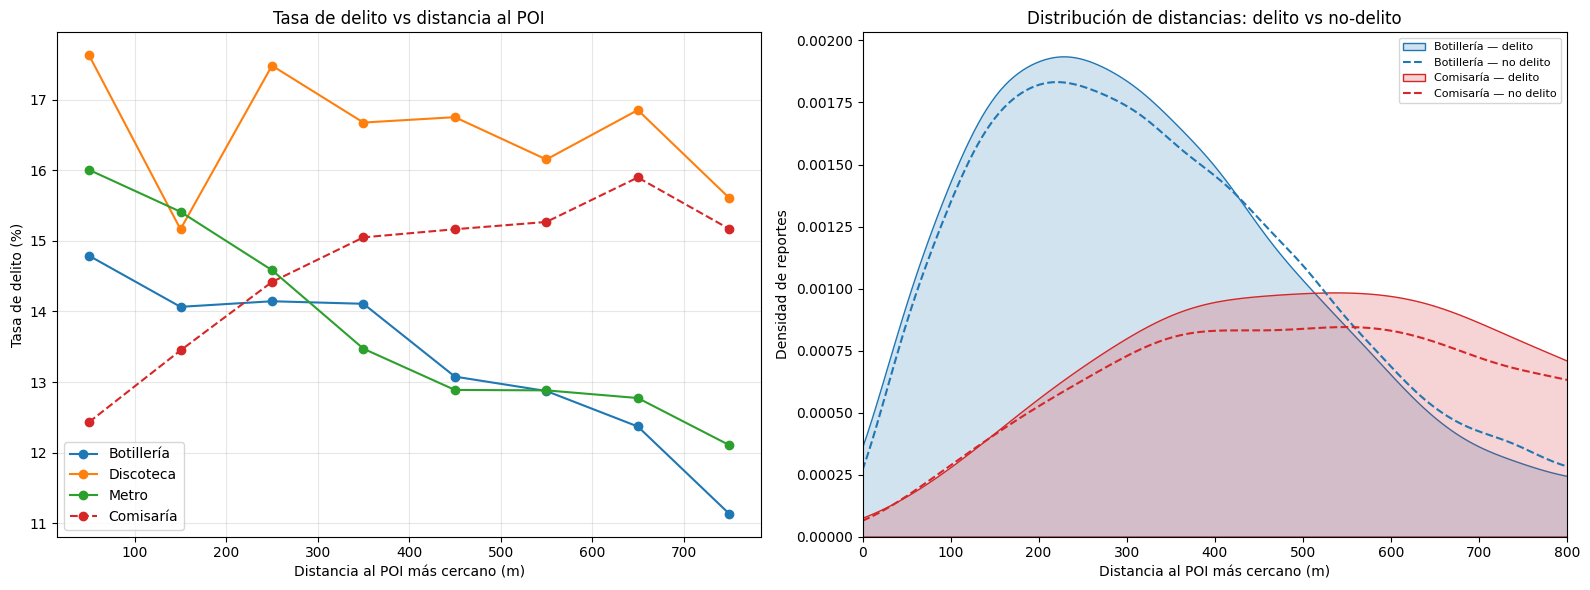

In [68]:
dd = pd.read_parquet('dataset_analitico.parquet', engine='fastparquet',
                     columns=['es_delito', 'dist_botilleria_m', 'dist_discoteca_m',
                              'dist_estacion_de_metro_m', 'dist_comisaria_m'])
cats = {'dist_botilleria_m': 'Botillería', 'dist_discoteca_m': 'Discoteca',
        'dist_estacion_de_metro_m': 'Metro', 'dist_comisaria_m': 'Comisaría'}
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# A) tasa de delito vs distancia (4 categorías) — hasta 800 m
bins = np.arange(0, 850, 100); centros = bins[:-1] + 50
for col, nom in cats.items():
    tasa = dd.groupby(pd.cut(dd[col], bins), observed=True)['es_delito'].mean().values * 100
    ls = '--' if nom == 'Comisaría' else '-'
    ax[0].plot(centros, tasa, marker='o', label=nom, ls=ls)
ax[0].set_xlabel('Distancia al POI más cercano (m)'); ax[0].set_ylabel('Tasa de delito (%)')
ax[0].set_title('Tasa de delito vs distancia al POI'); ax[0].legend(); ax[0].grid(alpha=0.3)

# B) delito vs no-delito: botillería (atractor) vs comisaría (disuasor)
for col, nom, color in [('dist_botilleria_m', 'Botillería', 'tab:blue'),
                        ('dist_comisaria_m', 'Comisaría', 'tab:red')]:
    sns.kdeplot(dd.loc[dd.es_delito, col], ax=ax[1], color=color, fill=True, alpha=0.2,
                label=f'{nom} — delito', clip=(0, 1000))
    sns.kdeplot(dd.loc[~dd.es_delito, col], ax=ax[1], color=color, ls='--',
                label=f'{nom} — no delito', clip=(0, 1000))
ax[1].set_xlabel('Distancia al POI más cercano (m)'); ax[1].set_ylabel('Densidad de reportes')
ax[1].set_title('Distribución de distancias: delito vs no-delito'); ax[1].set_xlim(0, 800)
ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

**Botillería** y **metro** muestran **decaimiento monótono** (a más distancia, menos delito): de **15,6 % a 0-50 m de una botillería → 9,2 % sobre 2 km**. La **comisaría es el caso distinto/inverso**: la tasa es **más baja justo al lado** (~12 % a 0-150 m), sube a un pico hacia ~650 m (15,9 %) y luego cae → sugiere un leve efecto **disuasivo en la vecindad inmediata**, mientras que las botillerías **atraen** delito. El efecto es real pero **moderado**.